Using Colab cache for faster access to the 'road-damage-dataset-potholes-cracks-and-manholes' dataset.
Dataset Path: /kaggle/input/road-damage-dataset-potholes-cracks-and-manholes
Total Images: 2009


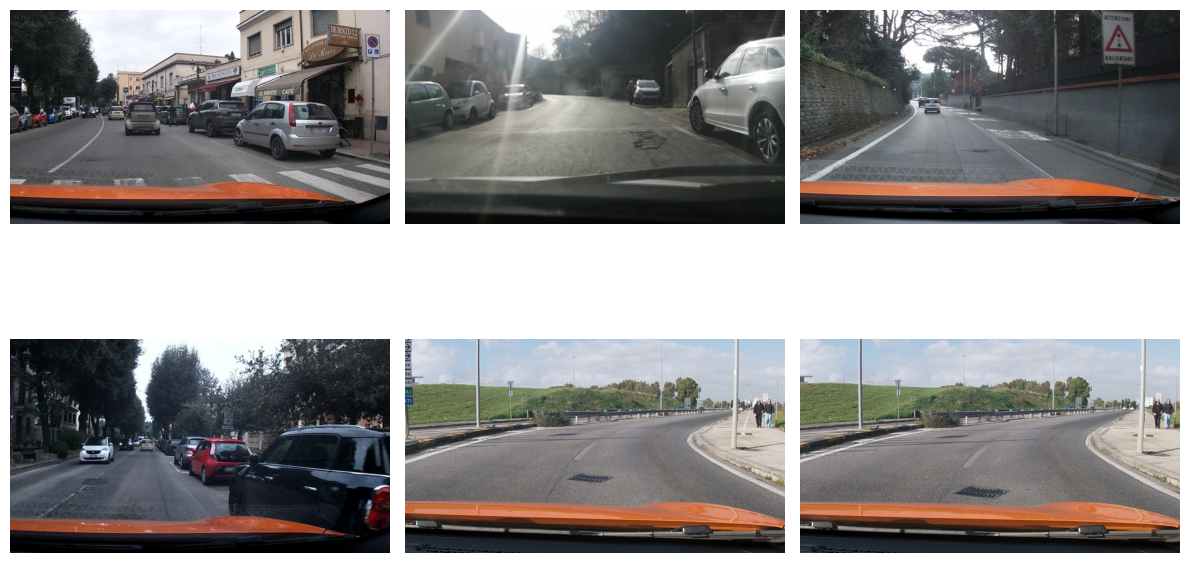

In [8]:
# ============================================
# IMPORT LIBRARIES
# ============================================

import kagglehub
import os
import cv2
import matplotlib.pyplot as plt

# ============================================
# LOAD DATASET USING KAGGLEHUB
# ============================================

dataset_path = kagglehub.dataset_download(
    "lorenzoarcioni/road-damage-dataset-potholes-cracks-and-manholes"
)

print("Dataset Path:", dataset_path)

# ============================================
# GET IMAGE PATHS
# ============================================

image_paths = []

for root, dirs, files in os.walk(dataset_path):

    for file in files:

        if file.endswith((".jpg", ".png", ".jpeg")):

            full_path = os.path.join(root, file)
            image_paths.append(full_path)

print("Total Images:", len(image_paths))

# ============================================
# SHOW SAMPLE IMAGES
# ============================================

plt.figure(figsize=(12, 8))

for i in range(6):

    img = cv2.imread(image_paths[i])

    # Convert BGR -> RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
# ============================================
# IMPORT LIBRARIES
# ============================================

import os
import cv2
import kagglehub
import matplotlib.pyplot as plt
from collections import Counter

# ============================================
# LOAD DATASET
# ============================================

dataset_path = kagglehub.dataset_download(
    "lorenzoarcioni/road-damage-dataset-potholes-cracks-and-manholes"
)

print("Dataset Path:", dataset_path)

# ============================================
# READ IMAGES + LABELS
# ============================================

image_paths = []
labels = []

for root, dirs, files in os.walk(dataset_path):

    for file in files:

        if file.endswith((".jpg", ".png", ".jpeg")):

            path = os.path.join(root, file)

            label = os.path.basename(root)

            image_paths.append(path)
            labels.append(label)

print("Total Images:", len(image_paths))

# ============================================
# NUMBER OF CLASSES
# ============================================

classes = sorted(list(set(labels)))

print("\nClasses:")
print(classes)

print("\nNumber of Classes:", len(classes))

# ============================================
# CLASS DISTRIBUTION
# ============================================

class_counts = Counter(labels)

print("\nClass Counts:")
print(class_counts)

Using Colab cache for faster access to the 'road-damage-dataset-potholes-cracks-and-manholes' dataset.
Dataset Path: /kaggle/input/road-damage-dataset-potholes-cracks-and-manholes
Total Images: 2009

Classes:
['images']

Number of Classes: 1

Class Counts:
Counter({'images': 2009})


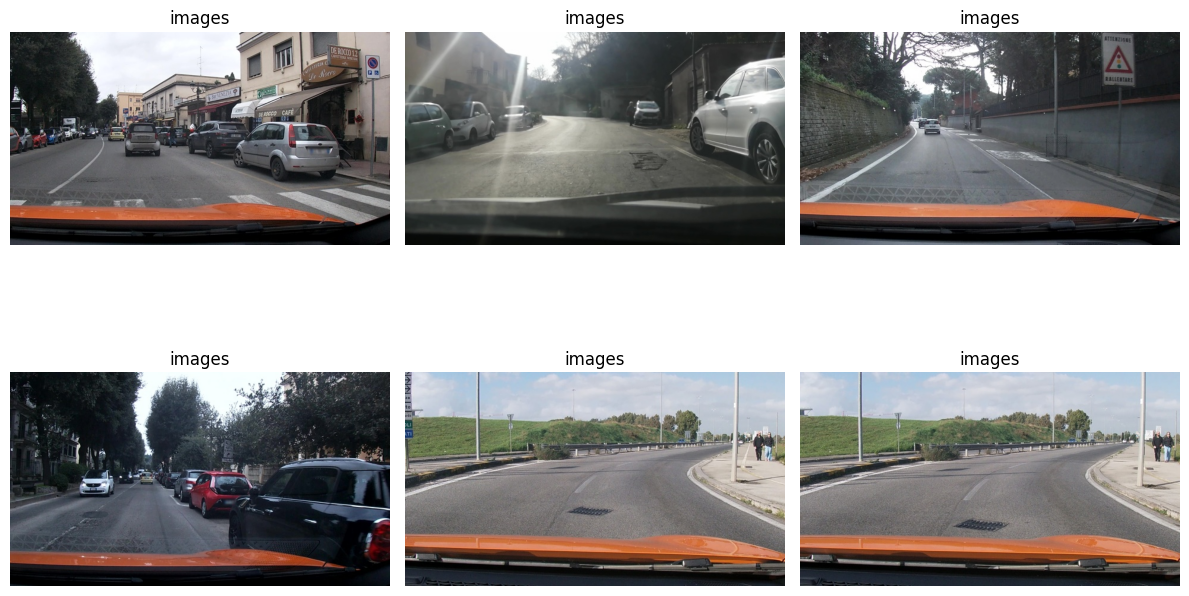

In [10]:
plt.figure(figsize=(12, 8))

for i in range(6):

    img = cv2.imread(image_paths[i])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(labels[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

IMG_SIZE = 128

X = []
y = []

# ============================================
# IMAGE PROCESSING
# ============================================

for path, label in zip(image_paths, labels):

    img = cv2.imread(path)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize image
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    # Normalize image
    img = img / 255.0

    X.append(img)
    y.append(label)

X = np.array(X)
y = np.array(y)

print("X Shape:", X.shape)

# ============================================
# LABEL ENCODING
# ============================================

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

print("Encoded Labels:", y_encoded[:10])

# ============================================
# TRAIN TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

X Shape: (2009, 128, 128, 3)
Encoded Labels: [0 0 0 0 0 0 0 0 0 0]
Train Shape: (1607, 128, 128, 3)
Test Shape: (402, 128, 128, 3)


In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(

    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    validation_split=0.2
)

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

model = Sequential()

# ============================================
# CONV BLOCK 1
# ============================================

model.add(Conv2D(
    32,
    (3, 3),
    activation='relu',
    input_shape=(128, 128, 3)
))

model.add(MaxPooling2D((2, 2)))

# ============================================
# CONV BLOCK 2
# ============================================

model.add(Conv2D(
    64,
    (3, 3),
    activation='relu'
))

model.add(MaxPooling2D((2, 2)))

# ============================================
# CONV BLOCK 3
# ============================================

model.add(Conv2D(
    128,
    (3, 3),
    activation='relu'
))

model.add(MaxPooling2D((2, 2)))

# ============================================
# FLATTEN
# ============================================

model.add(Flatten())

# ============================================
# DENSE LAYERS
# ============================================

model.add(Dense(128, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(len(classes), activation='softmax'))

# ============================================
# COMPILE MODEL
# ============================================

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model.fit(

    datagen.flow(
        X_train,
        y_train,
        batch_size=32
    ),

    epochs=15,

    validation_data=(X_test, y_test)
)

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


51/51 ━━━━━━━━━━━━━━━━━━━━ 18s 243ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 9s 169ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 7s 146ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 9s 167ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 5/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 8s 165ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 6/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 7s 145ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 7/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 9s 176ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Ep

In [14]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

import numpy as np

# ============================================
# PREDICTIONS
# ============================================

y_pred_probs = model.predict(X_test)

y_pred = np.argmax(y_pred_probs, axis=1)

# ============================================
# CLASSIFICATION REPORT
# ============================================

print(classification_report(
    y_test,
    y_pred,
    target_names=classes
))

# ============================================
# CONFUSION MATRIX
# ============================================

cm = confusion_matrix(y_test, y_pred)

print(cm)

/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step
              precision    recall  f1-score   support

      images       1.00      1.00      1.00       402

    accuracy                           1.00       402
   macro avg       1.00      1.00      1.00       402
weighted avg       1.00      1.00      1.00       402

[[402]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [15]:
wrong_indices = np.where(y_test != y_pred)[0]

print("Wrong Predictions:", len(wrong_indices))

Wrong Predictions: 0


In [17]:
def predict_image(path):

    img = cv2.imread(path)

    # Check if the image was loaded successfully
    if img is None:
        print(f"Error: Unable to load image from {path}")
        return

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = cv2.resize(img, (128, 128))

    img = img / 255.0

    img = np.expand_dims(img, axis=0)

    prediction = model.predict(img)

    class_index = np.argmax(prediction)

    predicted_label = encoder.inverse_transform([class_index])

    print("Prediction:", predicted_label[0])

# Example: Use the first image from the dataset
predict_image(image_paths[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 596ms/step
Prediction: images


In [18]:
model.save("road_damage_model.keras")